In [1]:
%load_ext autoreload

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

In [2]:
%autoreload 
from Fibernet2.Generator import Generator

In [3]:
hiperparams = {
    "geometry_file":"./example/LA_model.vtk",
    "create_TA_maps":True, # "fibers" must be on the geometry, if True "maps_files" ignored
    "maps_files":["LA_model_map1.csv", "LA_model_map2.csv", "LA_model_map3.csv"],
    "geometry_file_smooth":None, #"./data/LA_model_smooth_basis.vtk",
    # If "geometry_file_smooth":None , a basis will be generated.
    "area_multiplier":None,#1e-8,#micrometer2 to cm2: 1e-8|milimeter2 to cm2: 1e-2
    # If "area_multiplier":None , will be automatically defined
    # If "create_TA_maps":True , the following parameters are used
    "maps":3,
    "density":16, # ppm/area [points/cm2]
    "noise_ms":0,
    # The Eigfuns are only used for extended and laplace
    # We can import pre-calculated Eigen functions
    "input_precalculated": None,
    # In case we do not import pre-calculated Eigfuns
    "N_eig_max":200,
    "n_eigs":20, 
    "extend_n_layers":3,
    # Arquitecture hyperparameters
    "ensemble_size":10,
    "layers" : [20]*5 + [1],
    "CVlayers" : [20]*7 + [3],
    "lambda_prior":1e-2,
    "scaled":True,
    "CVmax":3.,
    # Training Hyperparameters
    "batch_size":64,
    "lambda_pde":1.e-4,
    "lambda_tve":1.e-7,
    "lambda_tva":1.e-9,
    "lambda_df":1.e0,
    "learning_rate":1e-3,
    # Random seeds
    "init_key":123, #it takes care of weight initialization
    "seed":456, #it takes care of the initial seed of the batches
    "gen_key_1":1651,#it takes care of initialitation of TAs
    "gen_key_2":1011,#it takes care of the sampling points
}

gen = Generator(hiperparams)
data = pv.UnstructuredGrid(gen.params["geometry_file"])
data.points *= np.sqrt(gen.params["area_multiplier"])

Function createbasis(<Fibernet2.Generator.Generator object at 0x0000016A8431B340>,) {} Took 3.3529 seconds
Function createmaps(<Fibernet2.Generator.Generator object at 0x0000016A8431B340>,) {} Took 70.7070 seconds


In [4]:
%autoreload 
from Fibernet2.Handler import Handler

models = {}
handlers = {}
for tmodel in ["delta",  "original"]:
    hiperparams["type_model"] = tmodel
    handlers[tmodel]=Handler(hiperparams, gen)
    models[tmodel]=handlers[tmodel].model

Original mesh has 33351 vertices and 66212 faces.
Extending holes on mesh with 3 layers of triangles...
Layer 01/03
Layer 02/03
Layer 03/03
5 holes extended
Extended mesh has 34839 vertices and 69188 faces.
Computing Laplacian
Computing eigen values
Function _init_delta(<Fibernet2.Generator.Generator object at 0x0000016A8431B340>,) {} Took 49.6755 seconds


In [5]:
for k in handlers.keys():
    handlers[k].train(int(1e4))

100%|██████████| 10000/10000 [01:36<00:00, 104.04it/s, loss=0.00012389456, loss_data=0.00012126998, loss_pde=0.026014194, loss_regu=(DeviceArray(0.22578984, dtype=float32), DeviceArray(0.5777552, dtype=float32))]


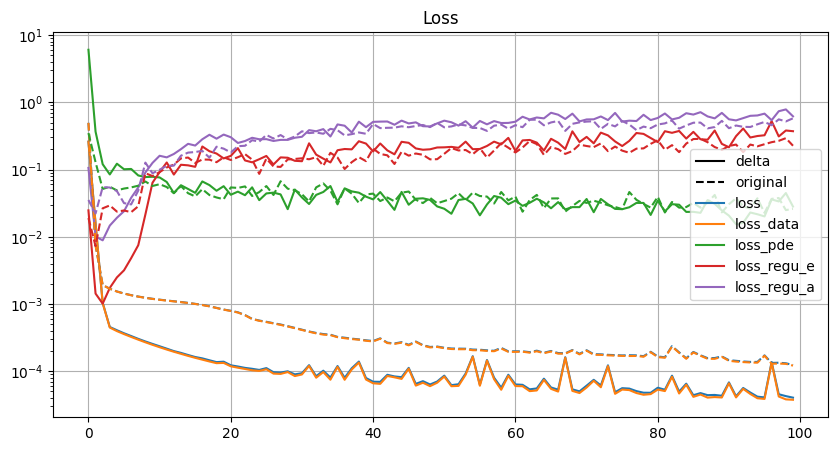

In [6]:
lf = ["-", "--", "."]
plt.figure(figsize=(10,5))
plt.title("Loss")
plt.semilogy()
for i, k in enumerate(models.keys()):
    plt.plot(models[k].training_log['loss'], lf[i])
    plt.plot(models[k].training_log['loss_data'], lf[i])
    plt.plot(models[k].training_log['loss_pde'], lf[i])
    plt.plot(models[k].training_log['loss_regu'], lf[i])
    plt.plot([],[], lf[i], c="k",label=k)
    plt.gca().set_prop_cycle(None)
    
plt.plot([],[],label="loss", ms=1)
plt.plot([],[],label="loss_data", ms=1)
plt.plot([],[],label="loss_pde", ms=1)
plt.plot([],[],label="loss_regu_e", ms=1)
plt.plot([],[],label="loss_regu_a", ms=1)
plt.grid()
plt.legend()
plt.show()

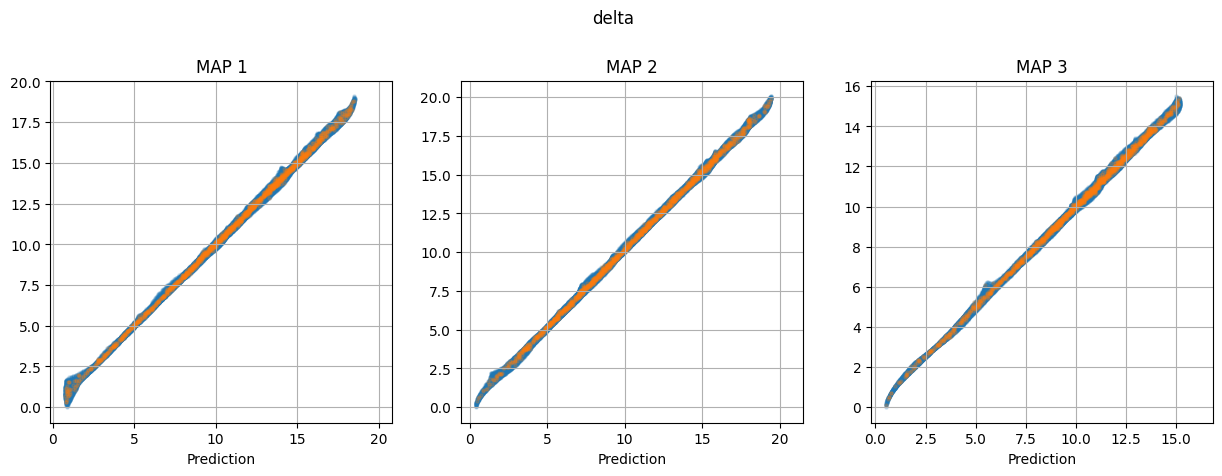

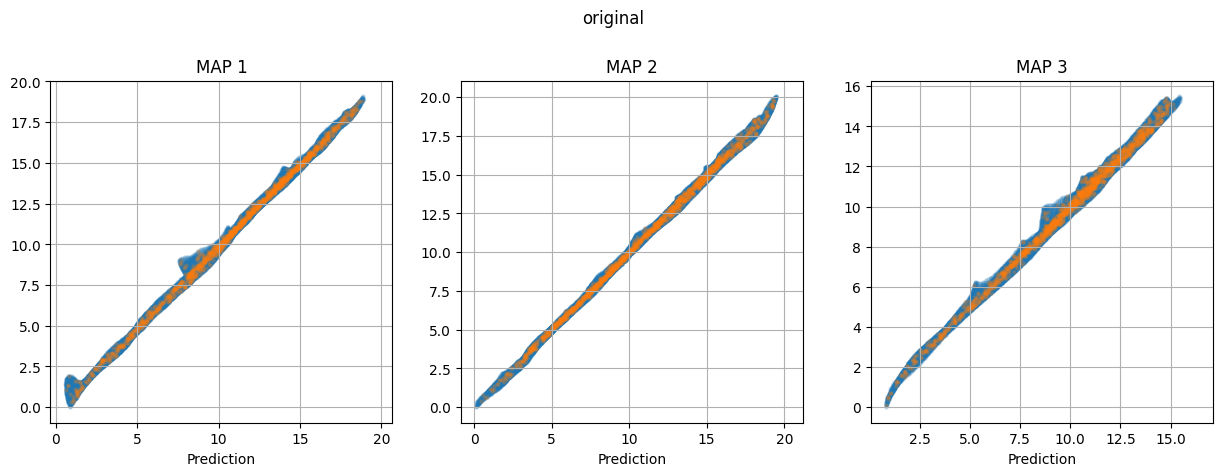

In [7]:
for j, tm in enumerate(models.keys()):
    sample_pred, pred, sample_true = handlers[tm].predictAT(return_times=True)
    maps_plot = pred.shape[-1]//3+pred.shape[-1]%3
    plt.figure(figsize=(15,5*maps_plot))
    plt.suptitle(tm)
    for i in range(pred.shape[-1]):
        plt.subplot(maps_plot,3,1+i)
        plt.title(f"MAP {i+1}")
        if hiperparams["create_TA_maps"]:
            # if not, the groundtruth does not exist
            plt.scatter(pred[:,i], gen.phis[:,i], alpha=0.2, s=5)
        plt.scatter(sample_pred[i], sample_true[i], alpha=0.2, s=5)
        plt.xlabel("Prediction")
        plt.grid()
        plt.axis("square")
    plt.show()